

OCR is actually two separate problems glued together, and conflating them is the #1 source of confusion:

Text detection — where is text in the image? (bounding boxes around text regions/lines/words)
Text recognition — given a cropped region that contains text, what does it say? (turning pixels into characters/strings)

A full OCR pipeline is: detect → crop each region → recognize each crop → assemble into a document.

What problem it solves

You have a photo of a receipt, an ID card, a scanned form — and you want structured, searchable text out of it instead of pixels.

Library landscape

Tesseract (pytesseract)	      Classic, mature, CPU-only, no deep learning by default in basic use

EasyOCR	                      Deep-learning based (CRNN + attention), handles detection+recognition	

PaddleOCR	                  Also deep-learning based, generally strong accuracy, faster than EasyOCR 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


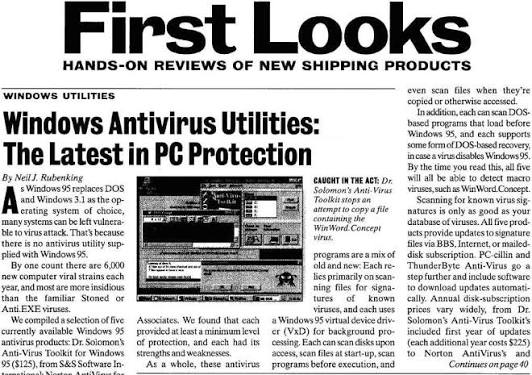


Detected Text:
First Looks

HANDS-ON REVIEWS OF NEW SHIPPING PRODUCTS

 

seen Ges when theyre

 

Windows Antivirus Utilities: Serco sates
The Latest in PC Protection

By Nels, Rubenking
A + Windows replaces DOS

  
  
  
  
    
   
 

tnd Windows 3 athe op-

rating system of choice,
many ots canbe kt vulcre
Me toviuratck. Tat beente

 

tes provide updatestostrature
fe Wa BBS, Inter, or aed
programsarearivof disk subsription PC lin and
sigandew Eachre-ThunderByte Ani-Vius go 4
Tesprimacyonscan- stepfurtber andincadevtware
Soy fe fo rato own pesto
ioe vey sib feet De

 

AGWEXE Vina

currently available Windows 98 providedatleastaminizumevel ct (

Sora prods Dr Soismoe\ of protection, ad each ha Sess
s

 

    

jomon’ Ant-Vius Tootki
included fir year of updates
‘ (cach ational er cost $25)
stengand wean, ‘moemtemflcratsar-up.cen 10" Norton Amira. and

re mrtava before execution aod Concent ompeae

 

   

 

      

 



In [5]:
import cv2
import pytesseract

from google.colab import drive
drive.mount('/content/drive')

from google.colab.patches import cv2_imshow

# Read image from Google Drive
image = cv2.imread('/content/drive/MyDrive/opencv/textdoc2.jpg')

# Check image
if image is None:
    print("Image not found. Check the path.")
else:

    # Display image
    cv2_imshow(image)

    # Perform OCR
    text = pytesseract.image_to_string(image)

    # Print extracted text
    print("\nDetected Text:")
    print(text)

In [9]:
%pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 9.2 MB/s eta 0:00:00


Image loaded successfully.
Text: Fist Looks
Confidence: 0.7901879009540244
Bounding Box: [[np.int32(60), 0], [np.int32(479), 0], [np.int32(479), np.int32(63)], [np.int32(60), np.int32(63)]]
--------------------------------------------------
Text: HANDS-ON REVIEWS OF NEW SHIPPING PRODUCTS
Confidence: 0.9652608577017893
Bounding Box: [[np.int32(61), np.int32(57)], [np.int32(473), np.int32(57)], [np.int32(473), np.int32(75)], [np.int32(61), np.int32(75)]]
--------------------------------------------------
Text: Wnen
Confidence: 0.645949125289917
Bounding Box: [[np.int32(476), np.int32(86)], [np.int32(498), np.int32(86)], [np.int32(498), np.int32(94)], [np.int32(476), np.int32(94)]]
--------------------------------------------------
Text: Ihey [
Confidence: 0.19965546453647867
Bounding Box: [[np.int32(502), np.int32(86)], [np.int32(530), np.int32(86)], [np.int32(530), np.int32(94)], [np.int32(502), np.int32(94)]]
--------------------------------------------------
Text: Windows UTILITIES
Co

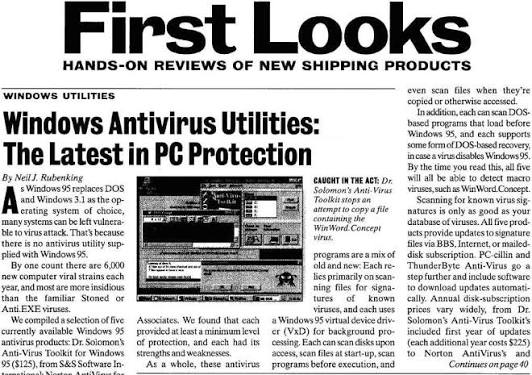

In [11]:
# ============================================================
# EASY OCR
# ============================================================

# Install first in Colab:
# %pip install easyocr


import cv2
import easyocr
from google.colab.patches import cv2_imshow


image_path = "/content/drive/MyDrive/opencv/textdoc2.jpg"

image = cv2.imread(image_path)

if image is None:
    print("Image not found. Check the path.")
else:
    print("Image loaded successfully.")


# ------------------------------------------------------------
# CREATE EASYOCR MODEL
# ------------------------------------------------------------

# ['en'] -> English OCR
# gpu=True -> use GPU if available
reader = easyocr.Reader(['en'], gpu=True)


# ------------------------------------------------------------
# OCR
# ------------------------------------------------------------

# EasyOCR detects text AND recognizes the text.
result = reader.readtext(image)


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

for detection in result:

    # detection contains:
    # [bounding_box, detected_text, confidence]

    box = detection[0]
    text = detection[1]
    confidence = detection[2]

    print("Text:", text)
    print("Confidence:", confidence)
    print("Bounding Box:", box)
    print("-" * 50)


# ------------------------------------------------------------
# DISPLAY IMAGE
# ------------------------------------------------------------

cv2_imshow(image)

In [ ]:
import sys
import paddle
import paddleocr
import paddlex

print("Python:", sys.version)
print("PaddlePaddle:", paddle.__version__)
print("PaddleOCR:", paddleocr.__version__)
print("PaddleX:", paddlex.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PaddlePaddle: 3.3.1
PaddleOCR: 3.7.0
PaddleX: 3.7.2
